<a href="https://colab.research.google.com/github/ldenarbonne/MLOpengouins/blob/1_productionizing_ML/bitcoin_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Projet Data Artefact/Filled_dataset.csv')
df.head()

Mounted at /content/drive


,timestamp,open,high,low,close,volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [ ]:
##Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px




import os

In [ ]:
##Data Exploration
print(df.head())
print(df.info())
print(df.describe())

      timestamp  open  high   low  close  volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7333361 entries, 0 to 7333360
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   timestamp  float64
 1   open       float64
 2   high       float64
 3   low        float64
 4   close      float64
 5   volume     float64
dtypes: float64(6)
memory usage: 335.7 MB
None
          timestamp          open          high           low         close  \
count  7.333361e+06  7.333361e+06  7.333361e+06  7.333361e+06  7.333361e+06   
mean   1.545413e+09  2.139632e+04  2.140400e+04  2.138844e+04  2.139632e+04   
std    1.270175e+08  3.005749e+04  3.006569e+04  3.004917e+04  3.005749e+04   
min    1.325412e+09  3.800000e+00  3.80

In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Filter the exact date range
mask = (df['date'] >= '2025-03-13') & (df['date'] <= '2025-03-17')
df_march = df[mask]

# Plot
plt.figure(figsize=(12,6))
plt.plot(df_march['date'], df_march['close'])
plt.title('Bitcoin Closing Price (2025-03-13 to 2025-03-17)')
plt.xlabel('date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()

KeyError: 'date'

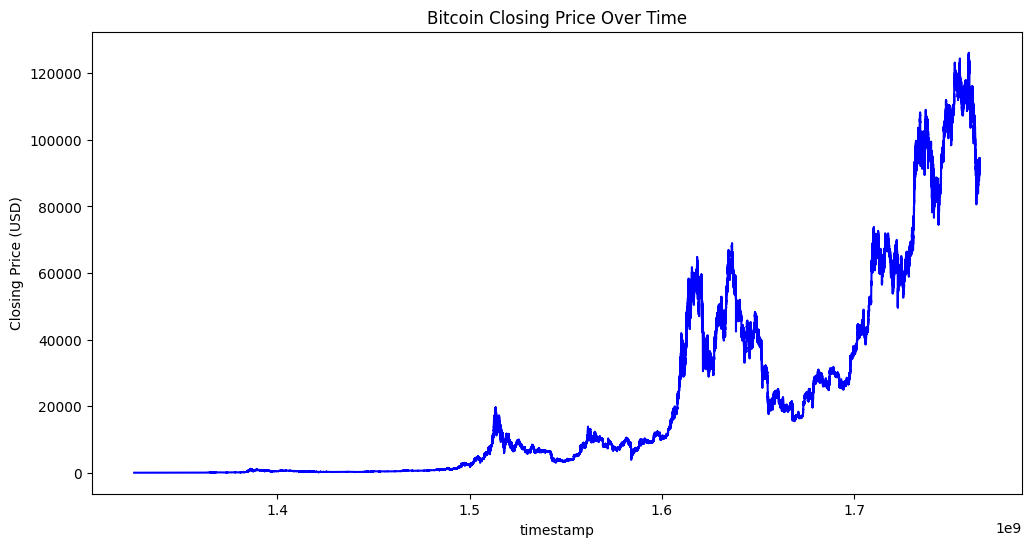

In [ ]:
#plot the closing price over time
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['close'], color='blue')
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('timestamp')
plt.ylabel('Closing Price (USD)')
plt.show()

In [ ]:
#convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

In [ ]:
##Data Exploration
print(df.head())
print(df.info())
print(df.describe())

            timestamp  open  high   low  close  volume
0 2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0
1 2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0
2 2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0
3 2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0
4 2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7333361 entries, 0 to 7333360
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   open       float64       
 2   high       float64       
 3   low        float64       
 4   close      float64       
 5   volume     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 335.7 MB
None
                           timestamp          open          high  \
count                        7333361  7.333361e+06  7.333361e+06   
mean   2018-12-21 17:20:59.999987712  2.139632e+04  2.140400e+04   
min              2012-01-01 10:01:00  3.

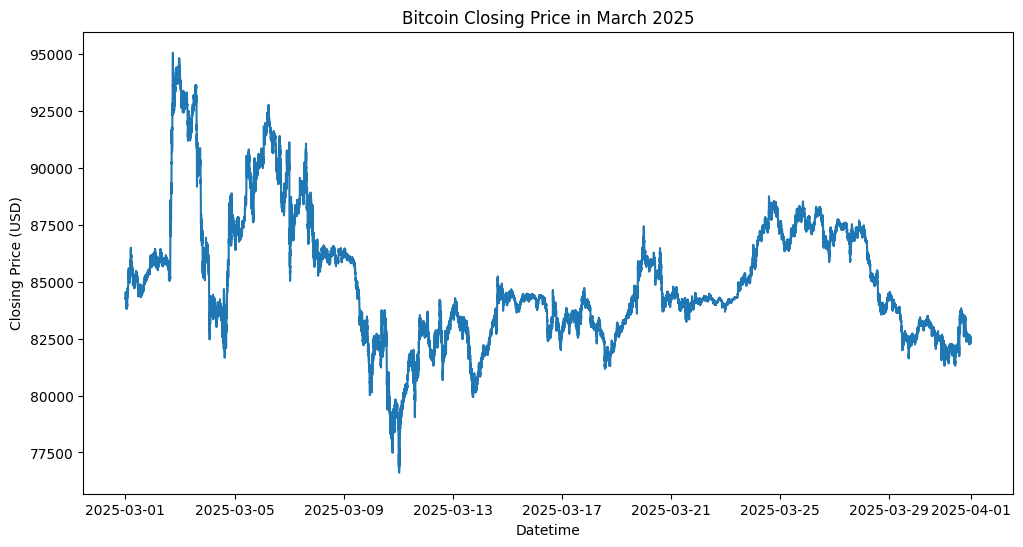

In [ ]:
plt.figure(figsize=(12,6))

df_march = df[(df['timestamp'].dt.year == 2025) &
              (df['timestamp'].dt.month == 3)]

plt.plot(df_march['timestamp'], df_march['close'])
plt.title('Bitcoin Closing Price in March 2025')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

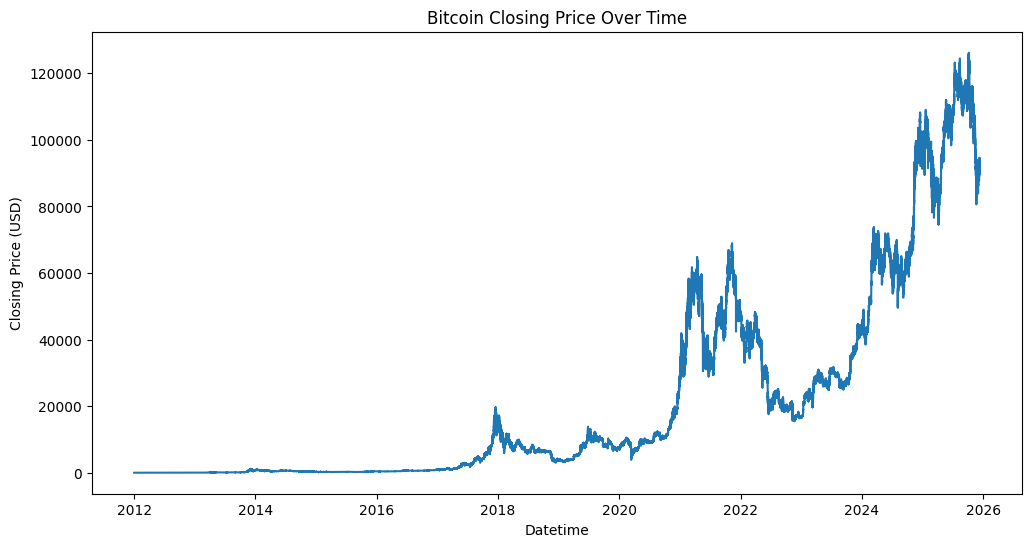

In [ ]:
#display the chart for the whole history
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['close'])
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

In [ ]:
#identify missing timestamps
df = df.set_index('timestamp')
all_timestamps = pd.date_range(start=df.index.min(), end=df.index.max(), freq='min')
missing_timestamps = all_timestamps.difference(df.index)
print(f"Number of missing timestamps: {len(missing_timestamps)}")
print(missing_timestamps)
#fill missing timestamps with NaN values
df = df.reindex(all_timestamps)
print(df.isnull().sum())


Number of missing timestamps: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='min')
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [ ]:
#timi based interlopation to fill missing values
df.interpolate(method='time', inplace=True)
print(df.isnull().sum())
#reset index
df = df.reset_index().rename(columns={'index': 'Timestamp'})
print(df.head())
#plot the closing price over time after filling missing values
plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Close'], color='green')
plt.title('Bitcoin Closing Price Over Time (After Filling Missing Values)')
plt.xlabel('Timestamp')
plt.ylabel('Closing Price (USD)')
plt.show()

open      0
high      0
low       0
close     0
volume    0
dtype: int64
            Timestamp  open  high   low  close  volume
0 2012-01-01 10:01:00  4.58  4.58  4.58   4.58     0.0
1 2012-01-01 10:02:00  4.58  4.58  4.58   4.58     0.0
2 2012-01-01 10:03:00  4.58  4.58  4.58   4.58     0.0
3 2012-01-01 10:04:00  4.58  4.58  4.58   4.58     0.0
4 2012-01-01 10:05:00  4.58  4.58  4.58   4.58     0.0


KeyError: 'Close'

<Figure size 1200x600 with 0 Axes>

In [ ]:
#plot log returns with time stamps converted to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Log_Returns'], color='orange')
plt.title('Bitcoin Log Returns Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Log Returns')
plt.show()

KeyError: 'Close'

In [ ]:
# Convertir timestamps Unix en datetime et définir l'index
#df['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
#df.set_index('datetime', inplace=True)
# Assurez-vous que l'index de New_dataest correct
#New_data['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
#New_data.set_index('datetime', inplace=True)
#21 h 43
print(df.index[:10])   # Affiche les 10 premiers index
print(type(df.index))

RangeIndex(start=0, stop=10, step=1)
<class 'pandas.core.indexes.range.RangeIndex'>


In [ ]:
df.shape

(1, 6)

In [ ]:
import pandas as pd
# Assurer que l'index est datetime
df.index = pd.to_datetime(df.index)
df = df.sort_index()
# Début exact du trou (confirmé par ton analyse)
start_gap = pd.to_datetime("2025-03-15 00:01:00")
# Créer le dataset propre (continu, sans trou)
best_data = df[df.index < start_gap]
# Vérifications
print("Dernier timestamp conservé :", best_data.index.max())
print("Nombre de lignes conservées :", len(best_data))
# Optionnel : aperçu
best_data.head(), best_data.tail()

Dernier timestamp conservé : 1970-01-01 00:00:00.007333360
Nombre de lignes conservées : 7333361


(                                        Timestamp  open  high   low  close  \
 1970-01-01 00:00:00.000000000 2012-01-01 10:01:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000001 2012-01-01 10:02:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000002 2012-01-01 10:03:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000003 2012-01-01 10:04:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000004 2012-01-01 10:05:00  4.58  4.58  4.58   4.58   
 
                                volume  
 1970-01-01 00:00:00.000000000     0.0  
 1970-01-01 00:00:00.000000001     0.0  
 1970-01-01 00:00:00.000000002     0.0  
 1970-01-01 00:00:00.000000003     0.0  
 1970-01-01 00:00:00.000000004     0.0  ,
                                         Timestamp     open     high      low  \
 1970-01-01 00:00:00.007333356 2025-12-11 00:37:00  91671.0  91671.0  91608.0   
 1970-01-01 00:00:00.007333357 2025-12-11 00:38:00  91656.0  91660.0  91443.0   
 1970-01-01 00:00:00.007333358 202

In [ ]:
print(df.index[:10])   # Affiche les 10 premiers index
print(type(df.index))

DatetimeIndex([          '1970-01-01 00:00:00',
               '1970-01-01 00:00:00.000000001',
               '1970-01-01 00:00:00.000000002',
               '1970-01-01 00:00:00.000000003',
               '1970-01-01 00:00:00.000000004',
               '1970-01-01 00:00:00.000000005',
               '1970-01-01 00:00:00.000000006',
               '1970-01-01 00:00:00.000000007',
               '1970-01-01 00:00:00.000000008',
               '1970-01-01 00:00:00.000000009'],
              dtype='datetime64[ns]', freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
# --- Time-based interpolation to fill missing values for March 2025 ---

# Filter March 2025 data
df_march = df[(df['Timestamp'].dt.year == 2025) &
              (df['Timestamp'].dt.month == 3)].copy()

# Ensure Timestamp is datetime
df_march['Timestamp'] = pd.to_datetime(df_march['Timestamp'])

# Set Timestamp as index
df_march = df_march.set_index('Timestamp')

# Create a complete index with 1-minute frequency
all_timestamps_march = pd.date_range(start=df_march.index.min(),
                                     end=df_march.index.max(),
                                     freq='1min')

# Identify missing timestamps
missing_timestamps_march = all_timestamps_march.difference(df_march.index)
print(f"Number of missing timestamps in March 2025: {len(missing_timestamps_march)}")
print(missing_timestamps_march)

# Reindex to insert missing timestamps (NaN Close values)
df_march = df_march.reindex(all_timestamps_march)

# Check missing values before interpolation
print("Missing values before interpolation:")
print(df_march.isnull().sum())

# Time-based interpolation
df_march.interpolate(method='time', inplace=True)

# Check missing values after interpolation
print("Missing values after interpolation:")
print(df_march.isnull().sum())

# --- Plot the results ---
plt.figure(figsize=(12, 6))
plt.plot(df_march.index, df_march['Close'], color='orange')
plt.title('Bitcoin Closing Price in March 2025 (After Filling Missing Values)')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

Number of missing timestamps in March 2025: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='min')
Missing values before interpolation:
open      0
high      0
low       0
close     0
volume    0
dtype: int64
Missing values after interpolation:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


KeyError: 'Close'

<Figure size 1200x600 with 0 Axes>

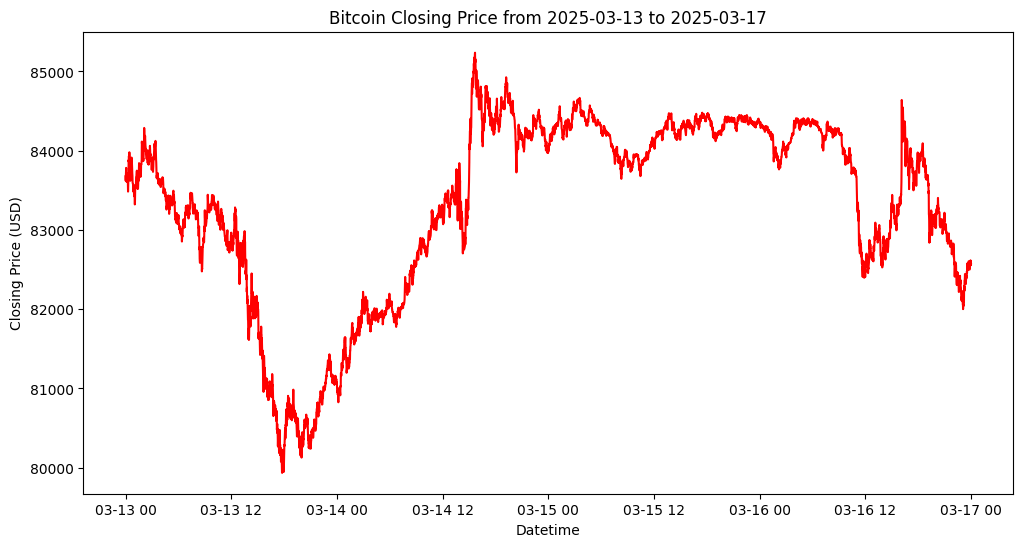

In [ ]:
# plot de bitcoin price between 2025-03-13 and 2025-03-17
df_march_period = df_march[(df_march.index >= '2025-03-13') & (df_march.index <= '2025-03-17')]
plt.figure(figsize=(12, 6))
plt.plot(df_march_period.index, df_march_period['close'], color='red')
plt.title('Bitcoin Closing Price from 2025-03-13 to 2025-03-17')
plt.xlabel('Datetime')
plt.ylabel('Closing Price (USD)')
plt.show()

In [ ]:
import pandas as pd

# show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# now print your slice
print(df_march_period)


                        open     high      low    close     volume
2025-03-13 00:00:00  83677.0  83677.0  83677.0  83677.0   0.000533
2025-03-13 00:01:00  83654.0  83654.0  83612.0  83621.0   0.262363
2025-03-13 00:02:00  83591.0  83684.0  83591.0  83684.0   0.000947
2025-03-13 00:03:00  83726.0  83731.0  83726.0  83731.0   0.000377
2025-03-13 00:04:00  83764.0  83783.0  83764.0  83783.0   0.005260
2025-03-13 00:05:00  83704.0  83704.0  83661.0  83668.0   0.002122
2025-03-13 00:06:00  83713.0  83713.0  83652.0  83665.0   0.130867
2025-03-13 00:07:00  83666.0  83686.0  83647.0  83666.0  12.719982
2025-03-13 00:08:00  83651.0  83651.0  83600.0  83606.0   0.130226
2025-03-13 00:09:00  83651.0  83683.0  83612.0  83683.0  10.127792
2025-03-13 00:10:00  83666.0  83715.0  83666.0  83715.0   0.386701
2025-03-13 00:11:00  83718.0  83718.0  83658.0  83658.0   0.591459
2025-03-13 00:12:00  83648.0  83690.0  83630.0  83690.0   7.057658
2025-03-13 00:13:00  83692.0  83692.0  83628.0  83628.0   0.23

In [ ]:
import pandas as pd
# Assurer que l'index est datetime
df.index = pd.to_datetime(df.index)
New_filleddf = df.sort_index()
# Début exact du trou (confirmé par ton analyse)
start_gap = pd.to_datetime("2025-03-15 00:01:00")
# Créer le dataset propre (continu, sans trou)
best_data = df[df.index < start_gap]
# Vérifications
print("Dernier timestamp conservé :", best_data.index.max())
print("Nombre de lignes conservées :", len(best_data))
# Optionnel : aperçu
best_data.head(), best_data.tail()

Dernier timestamp conservé : 1970-01-01 00:00:00.007333360
Nombre de lignes conservées : 7333361


(                                        Timestamp  open  high   low  close  \
 1970-01-01 00:00:00.000000000 2012-01-01 10:01:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000001 2012-01-01 10:02:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000002 2012-01-01 10:03:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000003 2012-01-01 10:04:00  4.58  4.58  4.58   4.58   
 1970-01-01 00:00:00.000000004 2012-01-01 10:05:00  4.58  4.58  4.58   4.58   
 
                                volume  
 1970-01-01 00:00:00.000000000     0.0  
 1970-01-01 00:00:00.000000001     0.0  
 1970-01-01 00:00:00.000000002     0.0  
 1970-01-01 00:00:00.000000003     0.0  
 1970-01-01 00:00:00.000000004     0.0  ,
                                         Timestamp     open     high      low  \
 1970-01-01 00:00:00.007333356 2025-12-11 00:37:00  91671.0  91671.0  91608.0   
 1970-01-01 00:00:00.007333357 2025-12-11 00:38:00  91656.0  91660.0  91443.0   
 1970-01-01 00:00:00.007333358 202

In [ ]:
print(df.index[:10])   # Affiche les 10 premiers index
print(type(df.index))

DatetimeIndex([          '1970-01-01 00:00:00',
               '1970-01-01 00:00:00.000000001',
               '1970-01-01 00:00:00.000000002',
               '1970-01-01 00:00:00.000000003',
               '1970-01-01 00:00:00.000000004',
               '1970-01-01 00:00:00.000000005',
               '1970-01-01 00:00:00.000000006',
               '1970-01-01 00:00:00.000000007',
               '1970-01-01 00:00:00.000000008',
               '1970-01-01 00:00:00.000000009'],
              dtype='datetime64[ns]', freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [ ]:
# split the data into train and test sets
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

In [ ]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 22.8 MB/s eta 0:00:00


In [ ]:
# run an arima model to predict bitcoin prices
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data['close'][:100000], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_data['Close'], predictions)
print(f'Mean Squared Error: {mse}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               100000
Model:                 ARIMA(5, 1, 0)   Log Likelihood              231553.884
Date:                Tue, 16 Dec 2025   AIC                        -463095.767
Time:                        11:35:38   BIC                        -463038.690
Sample:                    01-01-1970   HQIC                       -463078.445
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0649      0.000   -367.481      0.000      -0.065      -0.065
ar.L2          0.0020      0.001      1.438      0.150      -0.001       0.005
ar.L3          0.0020      0.005      0.442      0.6

KeyError: 'Close'

In [ ]:
# run a xgboost model to predict bitcoin prices

import yfinance as yf
import pandas as pd
import numpy as np

# Download Bitcoin data
df = yf.download("BTC-USD", start="2012-01-01")

# Feature engineering
df["return_1"] = df["Close"].pct_change(1)
df["return_5"] = df["Close"].pct_change(5)
df["return_10"] = df["Close"].pct_change(10)

df["lag_1"] = df["Close"].shift(1)
df["lag_2"] = df["Close"].shift(2)
df["lag_5"] = df["Close"].shift(5)

# Target: next day close
df["target"] = df["Close"].shift(-1)

df = df.dropna()
#3️⃣ Train / test split (time-series safe)

from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]

# No shuffling for time series
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
#4️⃣ Train XGBoost model

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)
#5️⃣ Evaluate performance
#python
#Copier le code
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")



/tmp/ipython-input-3680932280.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2012-01-01")
[*********************100%***********************]  1 of 1 completed


MAE:  19,954.78
RMSE: 28,155.38


/tmp/ipython-input-3273381918.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2016-01-01")
[*********************100%***********************]  1 of 1 completed


MAE:  22,242.41
RMSE: 29,594.89


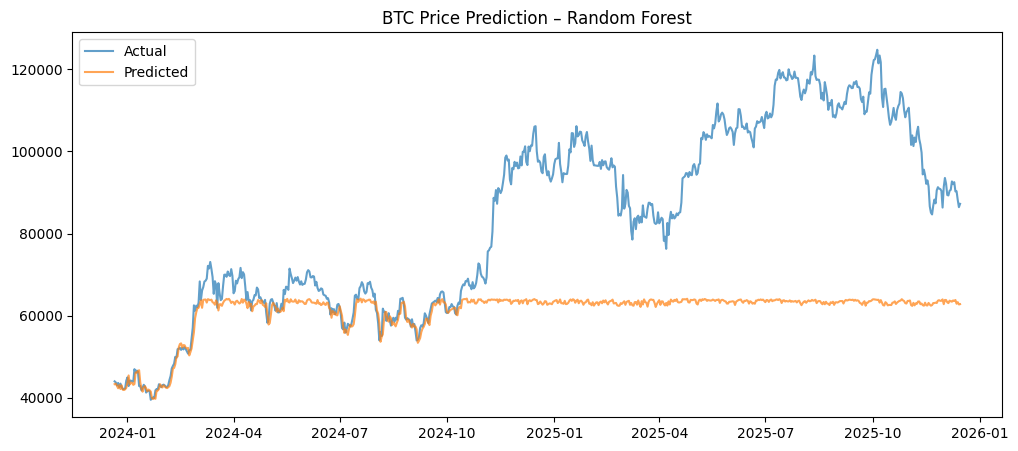

,,0
Price,Ticker,
Close,BTC-USD,0.244880
High,BTC-USD,0.204102
Low,BTC-USD,0.179489
lag_1,,0.133970
Open,BTC-USD,0.114601
lag_2,,0.064277
lag_5,,0.042384
Volume,BTC-USD,0.015120
return_10,,0.000383


In [ ]:
# run a random forest model to predict bitcoin prices
import yfinance as yf
import pandas as pd
import numpy as np

# Download BTC price data
df = yf.download("BTC-USD", start="2016-01-01")

# Feature engineering
df["return_1"] = df["Close"].pct_change(1)
df["return_5"] = df["Close"].pct_change(5)
df["return_10"] = df["Close"].pct_change(10)

df["lag_1"] = df["Close"].shift(1)
df["lag_2"] = df["Close"].shift(2)
df["lag_5"] = df["Close"].shift(5)

df["volume_change"] = df["Volume"].pct_change(1)

# Target: next-day close
df["target"] = df["Close"].shift(-1)

df = df.dropna()

from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

preds = rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual", alpha=0.7)
plt.plot(y_test.index, preds, label="Predicted", alpha=0.7)
plt.title("BTC Price Prediction – Random Forest")
plt.legend()
plt.show()

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)




In [ ]:
# run a LSTM model to predict bitcoin prices
import yfinance as yf

# Download Bitcoin data
btc = yf.download("BTC-USD", start="2015-01-01", end="2025-12-15")
btc.to_csv('btc_prices.csv')
print(btc.head())


import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load data
data = pd.read_csv('btc_prices.csv')
prices = data['Close'].values.reshape(-1, 1)

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length-1):
        X.append(data[i:(i+seq_length), 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

seq_length = 60
X, y = create_sequences(scaled_prices, seq_length)

# Train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test))

# Predict on test data
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title('Bitcoin Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()



/tmp/ipython-input-4010020423.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2015-01-01", end="2025-12-15")
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open    Volume
Ticker         BTC-USD     BTC-USD     BTC-USD     BTC-USD   BTC-USD
Date                                                                
2015-01-01  314.248993  320.434998  314.002991  320.434998   8036550
2015-01-02  315.032013  315.838989  313.565002  314.079010   7860650
2015-01-03  281.082001  315.149994  281.082001  314.846008  33054400
2015-01-04  264.195007  287.230011  257.612000  281.145996  55629100
2015-01-05  274.473999  278.341003  265.084015  265.084015  43962800


ValueError: could not convert string to float: 'BTC-USD'

In [ ]:
# run an arima model using yahoo finance data
from statsmodels.tsa.arima.model import ARIMA
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# 1. Download Bitcoin data
print("Downloading Bitcoin data...")
btc = yf.download("BTC-USD", start="2015-01-01", end="2025-12-15")
prices = btc['Close']

# 2. Check for stationarity
print("\nChecking stationarity...")
result = adfuller(prices)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# 3. Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8))
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(prices, lags=40, ax=ax1)
plot_pacf(prices, lags=40, ax=ax2)
plt.show()

# 4. Fit ARIMA model (auto-select parameters)
print("\nFitting ARIMA model...")
model = auto_arima(prices, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(model.summary())

# 5. Forecast next 30 days
forecast, conf_int = model.predict(n_periods=30, return_conf_int=True)
forecast_dates = pd.date_range(prices.index[-1], periods=31, freq='D')[1:]

# 6. Plot results
plt.figure(figsize=(12,6))
plt.plot(prices, label='Actual Price')
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.fill_between(forecast_dates, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.title('Bitcoin Price Forecast using ARIMA')
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'pmdarima'

/tmp/ipython-input-3260958909.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2015-01-01", end="2025-12-15")
[*********************100%***********************]  1 of 1 completed


Checking stationarity...


ADF Statistic: -0.8064219246485006
p-value: 0.8172283935024587


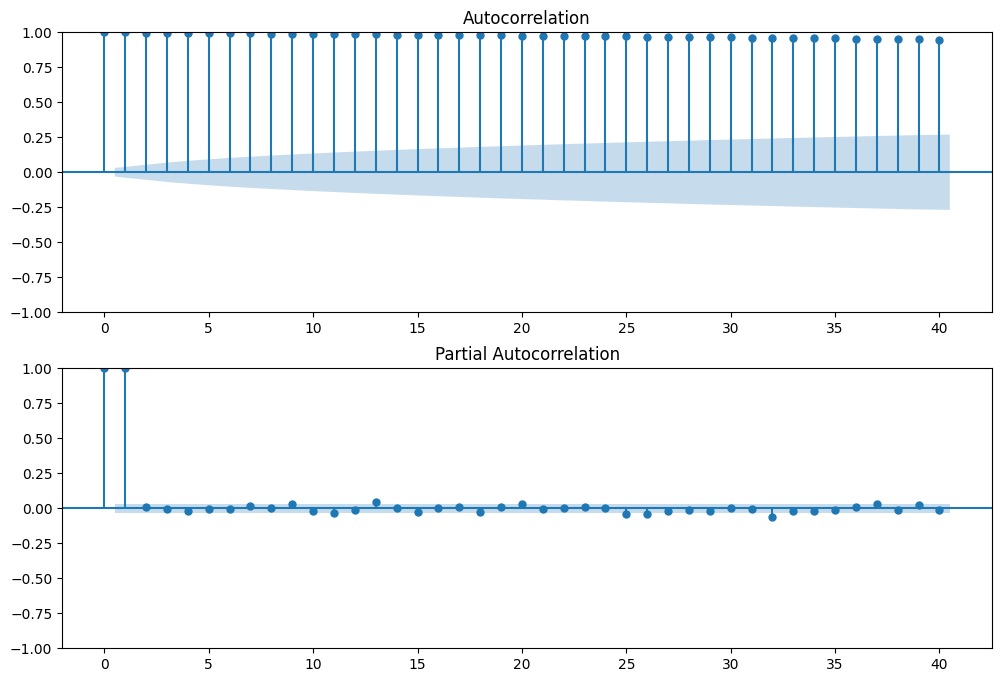


Fitting SARIMA model...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=67503.171, Time=11.81 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=67498.348, Time=0.27 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=67495.283, Time=2.00 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=67495.309, Time=1.90 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=67497.897, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=67493.287, Time=0.30 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=67495.283, Time=1.32 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=67497.283, Time=5.29 sec
 ARIMA(2,1,0)(0,0,0)[7] intercept   : AIC=67495.287, Time=0.62 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=67495.288, Time=1.35 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=67493.313, Time=0.64 sec
 ARIMA(2,1,1)(0,0,0)[7] intercept   : AIC=67497.289, Time=1.38 sec
 ARIMA(1,1,0)(0,0,0)[7]             : AIC=67492.974, Time=0.13 sec
 ARIMA(1,1,0)(1,0,0)[7]             : AIC=67494.973, Time=0.

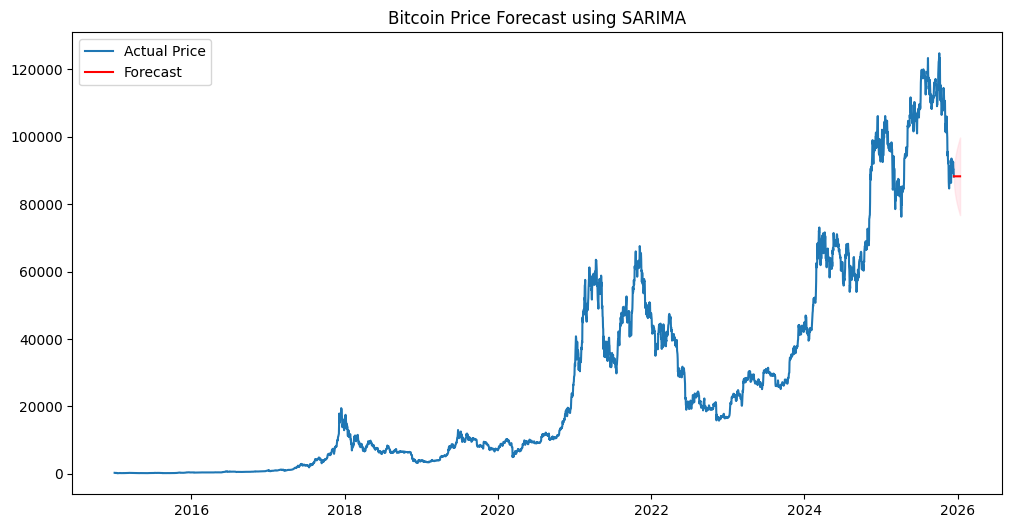

In [ ]:
# run a sarima model using yahoo finance data
# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Download Bitcoin data
print("Downloading Bitcoin data...")
btc = yf.download("BTC-USD", start="2015-01-01", end="2025-12-15")
prices = btc['Close']

# 2. Check for stationarity
print("\nChecking stationarity...")
result = adfuller(prices)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# 3. Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8))
plot_acf(prices, lags=40, ax=ax1)
plot_pacf(prices, lags=40, ax=ax2)
plt.show()

# 4. Fit SARIMA model (auto-select parameters)
print("\nFitting SARIMA model...")
# Note: For daily data, seasonal period is typically 7 (weekly seasonality)
model = auto_arima(prices, seasonal=True, m=7,
                   trace=True, error_action='ignore',
                   suppress_warnings=True, stepwise=True)
print(model.summary())

# 5. Forecast next 30 days
forecast, conf_int = model.predict(n_periods=30, return_conf_int=True)
forecast_dates = pd.date_range(prices.index[-1], periods=31, freq='D')[1:]

# 6. Plot results
plt.figure(figsize=(12,6))
plt.plot(prices, label='Actual Price')
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.fill_between(forecast_dates, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.title('Bitcoin Price Forecast using SARIMA')
plt.legend()
plt.show()



In [ ]:
# run an arima model to predict bitcoin prices
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data['close'][:100000], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_data['Close'], predictions)
print(f'Mean Squared Error: {mse}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               100000
Model:                 ARIMA(5, 1, 0)   Log Likelihood              231553.884
Date:                Tue, 16 Dec 2025   AIC                        -463095.767
Time:                        11:39:50   BIC                        -463038.690
Sample:                    01-01-1970   HQIC                       -463078.445
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0649      0.000   -367.481      0.000      -0.065      -0.065
ar.L2          0.0020      0.001      1.438      0.150      -0.001       0.005
ar.L3          0.0020      0.005      0.442      0.6

KeyError: 'Close'

In [ ]:
# run an arima model to predict bitcoin prices
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_data['close'][:100000], order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test_data['Close'], predictions)
print(f'Mean Squared Error: {mse}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:               100000
Model:                 ARIMA(5, 1, 0)   Log Likelihood              231553.884
Date:                Tue, 16 Dec 2025   AIC                        -463095.767
Time:                        11:40:51   BIC                        -463038.690
Sample:                    01-01-1970   HQIC                       -463078.445
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0649      0.000   -367.481      0.000      -0.065      -0.065
ar.L2          0.0020      0.001      1.438      0.150      -0.001       0.005
ar.L3          0.0020      0.005      0.442      0.6

KeyError: 'Close'

In [ ]:
# run a sarima model to predict bitcoin prices
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_data['close'][:100], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model




/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ns will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1 entries, 1970-01-01 to 1970-01-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Timestamp  1 non-null      datetime64[ns]
 1   open       0 non-null      float64       
 2   high       0 non-null      float64       
 3   low        0 non-null      float64       
 4   close      0 non-null      float64       
 5   volume     0 non-null      float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 56.0 bytes


In [ ]:
# plot the predictions
plt.figure(figsize=(12,6))
plt.plot(test_data.index, test_data['Close'], label='Actual Prices', color='blue    ')
plt.plot(test_data.index, predictions, label='Predicted Prices', color='red')
plt.title('Bitcoin Price Prediction using ARIMA Model')
plt.xlabel('Timestamp')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


NameError: name 'plt' is not defined

In [ ]:
# run a sarima model to predict bitcoin prices
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train_data['close'][:10], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()
print(model_fit.summary())
# make predictions
predictions = model_fit.forecast(steps=len(test_data))
# evaluate the model




/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will

LinAlgError: Schur decomposition solver error.

In [ ]:
# XGBoost Classifier
# Install xgboost if needed, import at top as required
%pip install xgboost --quiet
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBClassifier

# Train XGBoost on preprocessed features (use X_tr / X_te which are already available)
# Set eval_metric to avoid deprecation warnings in recent xgboost versions
xgb = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
xgb.fit(X_train, y_train)

# Make predictions with the XGBoost model and store them in y_pred so subsequent cells use the XGBoost predictions
y_pred = xgb.predict(X_train)

cm_xgb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=xgb.classes_, yticklabels=xgb.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost — Confusion Matrix")
plt.show()

# Use the preprocessed feature names for feature importances (X_train_final contains the preprocessed DF)
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("XGBoost Feature Importances")
plt.show()

NameError: name 'X_train' is not defined

In [ ]:
# XGBoost Classifier
# Install xgboost if needed, import at top as required
%pip install xgboost --quiet
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBClassifier

# Train XGBoost on preprocessed features (use X_tr / X_te which are already available)
# Set eval_metric to avoid deprecation warnings in recent xgboost versions
xgb = XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
xgb.fit(X_tr, y_train)

# Make predictions with the XGBoost model and store them in y_pred so subsequent cells use the XGBoost predictions
y_pred = xgb.predict(X_te)

cm_xgb = sklearn.metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=xgb.classes_, yticklabels=xgb.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost — Confusion Matrix")
plt.show()

# Use the preprocessed feature names for feature importances (X_train_final contains the preprocessed DF)
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train_final.columns)
feat_imp.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("XGBoost Feature Importances")
plt.show()

NameError: name 'X_tr' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Example for ARIMA/SARIMA
predictions = model_fit.predict(start=test_index[0], end=test_index[-1])
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse}, MAE: {mae}, MAPE: {mape}, R²: {r2}")

NameError: name 'model_fit' is not defined

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Load your data (replace with your actual data)
prices = pd.Series([...])  # Your Bitcoin price series

# Split into train and test
train_size = int(len(prices) * 0.8)
train, test = prices[:train_size], prices[train_size:]
test_index = test.index

In [ ]:
The error occurs because model_fit and test_index are not defined in your current code snippet. These variables should be set up after training your model and splitting your data into training and test sets.
Here’s a corrected, complete example for evaluating an ARIMA/SARIMA model:

1. Split Your Data
python
Copier

import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# Load your data (replace with your actual data)
prices = pd.Series([...])  # Your Bitcoin price series

# Split into train and test
train_size = int(len(prices) * 0.8)
train, test = prices[:train_size], prices[train_size:]
test_index = test.index



# Fit SARIMA model
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7))
model_fit = model.fit(disp=False)



SyntaxError: invalid character '’' (U+2019) (ipython-input-3980185368.py, line 2)

In [ ]:
# Fit SARIMA model
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7))
model_fit = model.fit(disp=False)


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
# Predict on test set
predictions = model_fit.predict(start=test_index[0], end=test_index[-1])

# Calculate metrics
rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions)
r2 = r2_score(test, predictions)

print(f"RMSE: {rmse}, MAE: {mae}, MAPE: {mape}, R²: {r2}")

NameError: name 'model_fit' is not defined

In [ ]:
import numpy as np
import pandas as pd

def create_features(df):
    df = df.copy()

    df["ret"] = np.log(df["close"]).diff()
    df["vol_20"] = df["ret"].rolling(20).std()
    df["mom_10"] = df["close"].pct_change(10)
    df["ema_20"] = df["close"].ewm(span=20).mean()
    df["ema_slope"] = df["ema_20"].diff()

    df = df.dropna()
    return df


In [ ]:
def trading_signal(pred, threshold=0.0005):
    if pred > threshold:
        return 1
    elif pred < -threshold:
        return -1
    return 0


In [ ]:
from sklearn.linear_model import Ridge

def walk_forward_backtest(
    df,
    train_window=500,
    fee=0.0005,   # 0.05% per trade
    threshold=0.0005
):
    df = create_features(df)

    features = ["vol_20", "mom_10", "ema_slope"]
    target = "ret"

    model = Ridge(alpha=1.0)

    positions = []
    pnl = []

    for i in range(train_window, len(df) - 1):
        train = df.iloc[i - train_window:i]
        test = df.iloc[i:i + 1]

        X_train = train[features]
        y_train = train[target]

        X_test = test[features]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)[0]

        pos = trading_signal(pred, threshold)
        positions.append(pos)

        next_ret = df.iloc[i + 1][target]
        trade_cost = fee if pos != 0 else 0

        pnl.append(pos * next_ret - trade_cost)

    results = pd.DataFrame({
        "pnl": pnl,
        "position": positions
    }, index=df.index[train_window + 1:])

    results["cum_pnl"] = results["pnl"].cumsum()
    return results


In [ ]:
def performance_metrics(results):
    sharpe = np.sqrt(252) * results["pnl"].mean() / results["pnl"].std()
    max_dd = (results["cum_pnl"].cummax() - results["cum_pnl"]).max()

    return {
        "Total Return": results["cum_pnl"].iloc[-1],
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd,
        "Win Rate": (results["pnl"] > 0).mean()
    }


In [ ]:

results = walk_forward_backtest(df)
metrics = performance_metrics(results)

print(metrics)
results["cum_pnl"].plot(title="Backtest Equity Curve")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Projet Data Artefact/Filled_dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,timestamp,open,high,low,close,volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [ ]:
results = walk_forward_backtest(df)
metrics = performance_metrics(results)

print(metrics)
results["cum_pnl"].plot(title="Backtest Equity Curve")


In [1]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

scores = cross_val_score(model, X, y, cv=kf)
print(scores.mean())


NameError: name 'X' is not defined

In [2]:
from sklearn.model_selection import StratifiedKFold


In [3]:
X = df.drop("target", axis=1)  # features
y = df["target"]               # class labels

NameError: name 'df' is not defined

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)


In [8]:
from sklearn.ensemble importfrom sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Per-fold accuracy:", scores)
print("Mean accuracy:", scores.mean())
print("Std:", scores.std())
 RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


SyntaxError: invalid syntax (ipython-input-391785791.py, line 1)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),  # remove if not needed
    ("model", model)
])

In [9]:
# F1-score
cross_val_score(pipe, X, y, cv=cv, scoring="f1_macro")

# ROC-AUC (binary classification)
cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")


NameError: name 'X' is not defined

In [10]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(pipe, X, y, cv=cv)


NameError: name 'X' is not defined